# Diabetes Risk Screening Model

This notebook builds the machine-learning artifact used by the Flask API. It follows the project flow from downloading the UCI Early Stage Diabetes Risk Prediction dataset to validating, evaluating, and saving a Logistic Regression pipeline.

The final model predicts the encoded target `class` (`Negative = 0`, `Positive = 1`). The API later presents these classes as `Lower` and `Higher` screening risk, not as a medical diagnosis.

In [88]:
import sys

print(sys.executable)


/home/omnitrix/Desktop/diabetes prediction/diabetes-risk-screening-spa/diabetes-risk-spa/.venv/bin/python


In [89]:
from ucimlrepo import fetch_ucirepo
early_stage_diabetes = fetch_ucirepo(id=529)

In [90]:
from ucimlrepo import fetch_ucirepo

early_stage_diabetes = fetch_ucirepo(id=529)

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 1. Load the reference dataset

The UCI repository is fetched with dataset id `529`. The next cells separate the questionnaire features (`X`) from the target (`y`) and inspect the sample rows, dimensions, column names, data types, allowed categorical values, and missing values. These checks confirm that the downloaded data matches the fields expected by the application.

In [91]:
X = early_stage_diabetes.data.features
y = early_stage_diabetes.data.targets

In [92]:
print("Features:")
print(X.head())

Features:
   age gender polyuria polydipsia sudden_weight_loss weakness polyphagia  \
0   40   Male       No        Yes                 No      Yes         No   
1   58   Male       No         No                 No      Yes         No   
2   41   Male      Yes         No                 No      Yes        Yes   
3   45   Male       No         No                Yes      Yes        Yes   
4   60   Male      Yes        Yes                Yes      Yes        Yes   

  genital_thrush visual_blurring itching irritability delayed_healing  \
0             No              No     Yes           No             Yes   
1             No             Yes      No           No              No   
2             No              No     Yes           No             Yes   
3            Yes              No     Yes           No             Yes   
4             No             Yes     Yes          Yes             Yes   

  partial_paresis muscle_stiffness alopecia obesity  
0              No              Yes      

In [93]:
print("Target:")
print(y.head())


Target:
      class
0  Positive
1  Positive
2  Positive
3  Positive
4  Positive


In [94]:
print("Number of rows:", X.shape[0])
print("Number of features:", X.shape[1])

Number of rows: 520
Number of features: 16


In [95]:
print(X.columns.tolist())


['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity']


In [96]:
print(y.columns)


Index(['class'], dtype='str')


In [97]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   age                 520 non-null    int64
 1   gender              520 non-null    str  
 2   polyuria            520 non-null    str  
 3   polydipsia          520 non-null    str  
 4   sudden_weight_loss  520 non-null    str  
 5   weakness            520 non-null    str  
 6   polyphagia          520 non-null    str  
 7   genital_thrush      520 non-null    str  
 8   visual_blurring     520 non-null    str  
 9   itching             520 non-null    str  
 10  irritability        520 non-null    str  
 11  delayed_healing     520 non-null    str  
 12  partial_paresis     520 non-null    str  
 13  muscle_stiffness    520 non-null    str  
 14  alopecia            520 non-null    str  
 15  obesity             520 non-null    str  
dtypes: int64(1), str(15)
memory usage: 65.1 KB


In [98]:
for column in X.columns:
    print(f"\n{column}")
    print(X[column].unique())


age
[40 58 41 45 60 55 57 66 67 70 44 38 35 61 54 43 62 39 48 32 42 52 53 37
 49 63 30 50 46 36 51 59 65 25 47 28 68 56 31 85 90 72 69 79 34 16 33 64
 27 29 26]

gender
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

polyuria
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

polydipsia
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

sudden_weight_loss
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

weakness
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

polyphagia
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

genital_thrush
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

visual_blurring
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

itching
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

irritability
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

delayed_healing
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

partial_paresis
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

muscle_stiffness
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

al

In [99]:
X.isnull().sum()

age                   0
gender                0
polyuria              0
polydipsia            0
sudden_weight_loss    0
weakness              0
polyphagia            0
genital_thrush        0
visual_blurring       0
itching               0
irritability          0
delayed_healing       0
partial_paresis       0
muscle_stiffness      0
alopecia              0
obesity               0
dtype: int64

In [100]:
y.isnull().sum()

class    0
dtype: int64

In [101]:
X.describe()

,age
count,520.000000
mean,48.028846
std,12.151466
min,16.000000
25%,39.000000
50%,47.500000
75%,57.000000
max,90.000000


## 2. Combine and audit the modeling data

The target column is temporarily joined to the feature table so the dataset can be inspected as one DataFrame. Class counts and the plot below show the balance between `Negative` and `Positive` examples before training.

In [102]:
df = X.copy()

df['class'] = y['class']

df.head()

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [103]:
df.shape

(520, 17)

In [104]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   age                 520 non-null    int64
 1   gender              520 non-null    str  
 2   polyuria            520 non-null    str  
 3   polydipsia          520 non-null    str  
 4   sudden_weight_loss  520 non-null    str  
 5   weakness            520 non-null    str  
 6   polyphagia          520 non-null    str  
 7   genital_thrush      520 non-null    str  
 8   visual_blurring     520 non-null    str  
 9   itching             520 non-null    str  
 10  irritability        520 non-null    str  
 11  delayed_healing     520 non-null    str  
 12  partial_paresis     520 non-null    str  
 13  muscle_stiffness    520 non-null    str  
 14  alopecia            520 non-null    str  
 15  obesity             520 non-null    str  
dtypes: int64(1), str(15)
memory usage: 65.1 KB


In [105]:
X.isnull().sum()

age                   0
gender                0
polyuria              0
polydipsia            0
sudden_weight_loss    0
weakness              0
polyphagia            0
genital_thrush        0
visual_blurring       0
itching               0
irritability          0
delayed_healing       0
partial_paresis       0
muscle_stiffness      0
alopecia              0
obesity               0
dtype: int64

In [106]:
y['class'].value_counts()

class
Positive    320
Negative    200
Name: count, dtype: int64

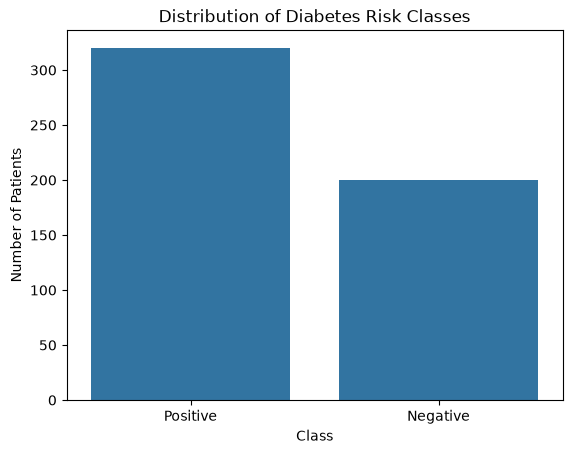

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=y['class'])

plt.title('Distribution of Diabetes Risk Classes')
plt.xlabel('Class')
plt.ylabel('Number of Patients')

plt.show()

In [108]:
for column in df.columns:
    if df[column].dtype == 'object':
        print(f"\n{column}")
        print(df[column].value_counts())

In [109]:
df_encoded = df.copy()

## 3. Encode questionnaire values

The API receives human-readable answers, but the estimator requires numeric inputs. The binary symptom fields are mapped from `No/Yes` to `0/1`, gender from `Female/Male` to `0/1`, and the target from `Negative/Positive` to `0/1`. Missing-value checks after encoding verify that the mappings did not create gaps.

In [110]:
binary_columns = [
    'polyuria',
    'polydipsia',
    'sudden_weight_loss',
    'weakness',
    'polyphagia',
    'genital_thrush',
    'visual_blurring',
    'itching',
    'irritability',
    'delayed_healing',
    'partial_paresis',
    'muscle_stiffness',
    'alopecia',
    'obesity'
]

In [111]:
for column in binary_columns:
    df_encoded[column] = df_encoded[column].map({
        'Yes': 1,
        'No': 0
    })

In [112]:
df_encoded.head()

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
0,40,Male,0,1,0,1,0,0,0,1,0,1,0,1,1,1,Positive
1,58,Male,0,0,0,1,0,0,1,0,0,0,1,0,1,0,Positive
2,41,Male,1,0,0,1,1,0,0,1,0,1,0,1,1,0,Positive
3,45,Male,0,0,1,1,1,1,0,1,0,1,0,0,0,0,Positive
4,60,Male,1,1,1,1,1,0,1,1,1,1,1,1,1,1,Positive


In [113]:
df_encoded['gender'] = df_encoded['gender'].map({
    'Female': 0,
    'Male': 1
})

In [114]:
df_encoded['gender'].value_counts()

gender
1    328
0    192
Name: count, dtype: int64

In [115]:
df_encoded['class'] = df_encoded['class'].map({
    'Negative': 0,
    'Positive': 1
})

In [116]:
df_encoded['class'].value_counts()

class
1    320
0    200
Name: count, dtype: int64

In [117]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   age                 520 non-null    int64
 1   gender              520 non-null    int64
 2   polyuria            520 non-null    int64
 3   polydipsia          520 non-null    int64
 4   sudden_weight_loss  520 non-null    int64
 5   weakness            520 non-null    int64
 6   polyphagia          520 non-null    int64
 7   genital_thrush      520 non-null    int64
 8   visual_blurring     520 non-null    int64
 9   itching             520 non-null    int64
 10  irritability        520 non-null    int64
 11  delayed_healing     520 non-null    int64
 12  partial_paresis     520 non-null    int64
 13  muscle_stiffness    520 non-null    int64
 14  alopecia            520 non-null    int64
 15  obesity             520 non-null    int64
 16  class               520 non-null    int64
dtypes: int64

In [118]:
df_encoded.isnull().sum()

age                   0
gender                0
polyuria              0
polydipsia            0
sudden_weight_loss    0
weakness              0
polyphagia            0
genital_thrush        0
visual_blurring       0
itching               0
irritability          0
delayed_healing       0
partial_paresis       0
muscle_stiffness      0
alopecia              0
obesity               0
class                 0
dtype: int64

In [119]:
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

In [120]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (520, 16)
y shape: (520,)


In [121]:
from sklearn.model_selection import train_test_split

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## 4. Create a reproducible train/test split

The encoded target is separated from the input features, then the data is split into 80% training and 20% testing sets. `stratify=y` preserves the class proportions in both sets, while `random_state=42` makes the split reproducible.

In [123]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (416, 16)
Testing data: (104, 16)


In [124]:
from sklearn.linear_model import LogisticRegression

In [125]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

## 5. Train a baseline Logistic Regression model

This first estimator provides a simple reference point without feature scaling. Its predictions, probabilities, accuracy, classification report, and confusion matrix show how well the raw encoded features perform on the held-out test set.

In [126]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [127]:
y_pred = model.predict(X_test)

In [128]:
print(y_pred[:20])

[0 1 1 0 0 1 1 0 1 0 1 1 1 1 1 1 0 0 1 1]


In [129]:
y_probability = model.predict_proba(X_test)

print(y_probability[:5])

[[0.71407121 0.28592879]
 [0.08612618 0.91387382]
 [0.01053172 0.98946828]
 [0.67500524 0.32499476]
 [0.91298942 0.08701058]]


In [130]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9423076923076923


In [131]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['Lower', 'Higher']
))

              precision    recall  f1-score   support

       Lower       0.89      0.97      0.93        40
      Higher       0.98      0.92      0.95        64

    accuracy                           0.94       104
   macro avg       0.93      0.95      0.94       104
weighted avg       0.95      0.94      0.94       104



In [132]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[39  1]
 [ 5 59]]


In [133]:
symptom_columns = [
    'polyuria',
    'polydipsia',
    'sudden_weight_loss',
    'weakness',
    'polyphagia',
    'genital_thrush',
    'visual_blurring',
    'itching',
    'irritability',
    'delayed_healing',
    'partial_paresis',
    'muscle_stiffness',
    'alopecia',
    'obesity'
]

In [134]:
symptom_rates = df.groupby('class')[symptom_columns].apply(
    lambda x: (x == 'Yes').mean() * 100
)

symptom_rates

,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity
class,,,,,,,,,,,,,,
Negative,7.5000,4.0000,14.50,43.500,24.0000,16.5000,29.0000,49.500,8.000,43.0000,16.0,30.0000,50.500,13.5000
Positive,75.9375,70.3125,58.75,68.125,59.0625,25.9375,54.6875,48.125,34.375,47.8125,60.0,42.1875,24.375,19.0625


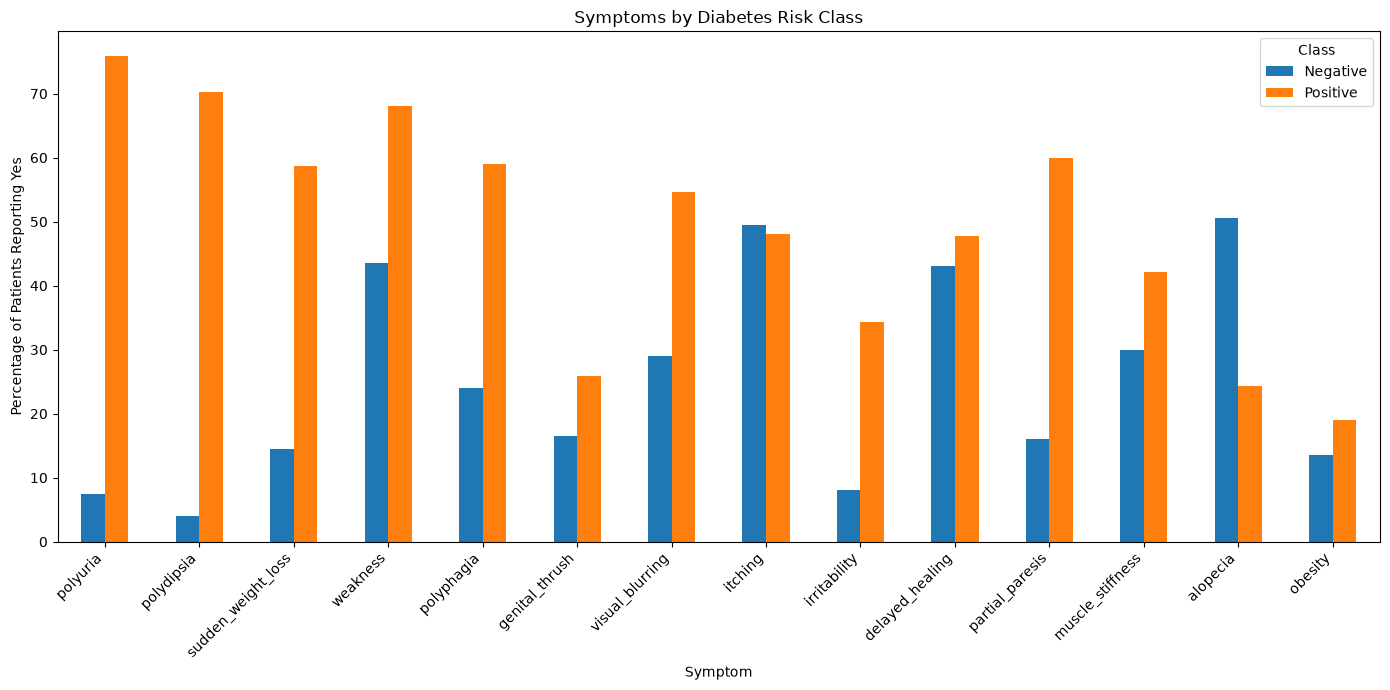

In [135]:
symptom_rates.T.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Symptoms by Diabetes Risk Class')
plt.xlabel('Symptom')
plt.ylabel('Percentage of Patients Reporting Yes')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Class')

plt.tight_layout()
plt.show()

## 6. Inspect symptom patterns

This descriptive analysis is separate from model training. It compares the percentage of `Yes` responses for each symptom across the original `Negative` and `Positive` groups, helping explain the dataset without changing the fitted model.

In [136]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [137]:
logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

## 7. Train the final preprocessing pipeline

The final estimator combines `StandardScaler` with Logistic Regression in one `Pipeline`. Keeping scaling and prediction together ensures that training-time preprocessing is automatically repeated when the saved model receives API input.

In [138]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','gender','polyuria',...,'muscle_stiffness','alopecia','obesity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [139]:
y_pred = logistic_model.predict(X_test)

In [140]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100)

Accuracy: 0.9423076923076923
Accuracy percentage: 94.23076923076923


## 8. Evaluate the final pipeline

The final pipeline is evaluated on the same untouched test set. Accuracy summarizes overall correctness, the classification report separates performance for `Lower` and `Higher`, and the confusion matrix shows the count of each correct and incorrect class prediction.

In [141]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['Lower', 'Higher']
))

              precision    recall  f1-score   support

       Lower       0.89      0.97      0.93        40
      Higher       0.98      0.92      0.95        64

    accuracy                           0.94       104
   macro avg       0.93      0.95      0.94       104
weighted avg       0.95      0.94      0.94       104



In [142]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[39  1]
 [ 5 59]]


In [143]:
coefficients = logistic_model.named_steps[
    'logistic_regression'
].coef_[0]

In [144]:
import pandas as pd
coefficient_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': coefficients
})

coefficient_df = coefficient_df.sort_values(
    by='coefficient',
    ascending=False
)

coefficient_df

,feature,coefficient
3,polydipsia,1.928797
2,polyuria,1.610607
10,irritability,0.809419
7,genital_thrush,0.557659
6,polyphagia,0.551056
12,partial_paresis,0.447266
8,visual_blurring,0.317094
4,sudden_weight_loss,0.255456
5,weakness,0.246558
14,alopecia,-0.061075


In [146]:
import joblib
joblib.dump(
    logistic_model,
    './model/diabetes_risk_model.pkl'
)

['./model/diabetes_risk_model.pkl']

## 9. Export the deployable model

The fitted pipeline is serialized to `model/diabetes_risk_model.pkl`. This file contains both the scaler and Logistic Regression estimator, so the API can load one artifact and call `predict` or `predict_proba` for incoming questionnaire data.

In [149]:
import os
os.path.getsize('./model/diabetes_risk_model.pkl')

2321

In [150]:
import joblib

loaded_model = joblib.load(
    './model/diabetes_risk_model.pkl'
)

In [151]:
loaded_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','gender','polyuria',...,'muscle_stiffness','alopecia','obesity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [152]:
test_prediction = loaded_model.predict(X_test)

print(test_prediction[:10])

[0 1 1 0 0 1 1 0 1 0]


In [153]:
test_probability = loaded_model.predict_proba(X_test)

print(test_probability[:5])

[[0.71933384 0.28066616]
 [0.02099465 0.97900535]
 [0.0029092  0.9970908 ]
 [0.68727675 0.31272325]
 [0.95051044 0.04948956]]


In [154]:
feature_order = [
    'age',
    'gender',
    'polyuria',
    'polydipsia',
    'sudden_weight_loss',
    'weakness',
    'polyphagia',
    'genital_thrush',
    'visual_blurring',
    'itching',
    'irritability',
    'delayed_healing',
    'partial_paresis',
    'muscle_stiffness',
    'alopecia',
    'obesity'
]

## 10. Preserve the API feature contract

The feature list records the exact column order expected during inference: age, gender, and the 14 binary symptom/sign fields. It is saved separately as `model/feature_order.pkl`; `api/app.py` uses the same order when constructing its one-row DataFrame.

In [155]:
joblib.dump(
    feature_order,
    './model/feature_order.pkl'
)

['./model/feature_order.pkl']

In [156]:
model.predict()

TypeError: LinearClassifierMixin.predict() missing 1 required positional argument: 'X'

The next cell intentionally calls `model.predict()` without the required input argument. It is an error probe rather than a required training step; it can be skipped when running the notebook from top to bottom. The following cells repeat the export and reload verification.

In [158]:
import joblib

joblib.dump(
    logistic_model,
    './model/diabetes_risk_model.pkl'
)

['./model/diabetes_risk_model.pkl']

In [159]:
import os

print(os.path.exists('./model/diabetes_risk_model.pkl'))
print(os.path.getsize('./model/diabetes_risk_model.pkl'))

True
2321


In [160]:
loaded_model = joblib.load(
    './model/diabetes_risk_model.pkl'
)

print(loaded_model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic_regression',
                 LogisticRegression(max_iter=1000, random_state=42))])


## 11. Reload and verify the saved artifact

The model is loaded from disk and used for test predictions and probabilities. This check confirms that the serialized artifact behaves like the in-memory pipeline before Flask loads it.

In [161]:
test_prediction = loaded_model.predict(X_test)

print(test_prediction[:10])

[0 1 1 0 0 1 1 0 1 0]
